##  AI-мониторинг диабетической стопы

###  Какую проблему решает продукт?
В России фиксируется ~5–6 млн пациентов с сахарным диабетом (официальная статистика). У 30–80% из них развиваются хронические дефекты стоп, ведущие к инфекциям, остеомиелиту и ампутациям.
Основная проблема — **отсутствие объективного, стандартизированного и доступного инструмента для мониторинга ран**:
- Врачи измеряют площадь линейкой/плёнкой вручную → погрешность 15–30%, трата 5–10 мин на пациента
- Нет цифрового трекинга динамики заживления
- Пациенты не могут самостоятельно отслеживать ухудшения между визитами
- Дефицит профильных специалистов (подиатров, хирургов) в регионах РФ

Результаты экспериментов с моделями из прошлого урока представлены в таблице ниже. В качестве метрик для всех моделей используются `Dice`, `IoU`, `precision`, `recall`.

| Параметр | Unet + efficientnet-b0 | Unet + MIT | DeepLabV3 + efficientnet-b0| Fine-tune Unet + efficientnet-b0|
|----------|----------|----------|----------|------------|
| **Dice** | 0.9039| 0.8968| 0.8678| 0.8643|
| **IoU** | 0.8247| 0.8129| 0.7665| 0.7610|
| **Precision** | 0.8957 | 0.8703| 0.8472| 0.8392|
| **Recall** | 0.9123 | 0.9250| 0.8894| 0.8908|
| **Функция потерь** | 0.1049| 0.1201| 0.1465| 0.1458| 
| **Лучшая эпоха обучения** | 24 | 15| 14| 1|


#### Для оценки обобщающей способности моделей было проведено кросс-датасетное тестирование на датасете DFUC2022 (Diabetic Foot Ulcer Challenge 2022)

#### В результате получили следующие значения метрик на новых данных из датасета DFUC2022

| Параметр | Unet + efficientnet-b0 | Unet + MIT | DeepLabV3 + efficientnet-b0| Fine-tune (Unet + efficientnet-b0)|
|----------|----------|----------|----------|----------|
| **Dice** | 0.6673| 0.6727| 0.6073| 0.5973|
| **IoU** | 0.5007| 0.5068| 0.4361| 0.4258|
| **Precision** | 0.8845 | 0.7134| 0.8847| 0.8308|
| **Recall** | 0.5358 | 0.6364| 0.4624| 0.4662|

Несмотря на лучшие показания метрик на датасете `FuSeg`, модель `Unet + efficientnet-b0` просела на новых данных. При высокой точности модель имеет слишком низкий recall, из-за чего проседает `Dice`. В то же время модель `Unet + MIT` демонстрирует хорошую обобщающую способность за счет механизма внимания. Несмотря на мультимасштабный модуль ASPP, `DeepLabV3 + efficientnet-b0` показывает низкие метрики.

#### 1. Пайплайн предобработки / FE / генерации данных

В качестве предобработки данных используются аугментации.

In [89]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import cv2
from tqdm import tqdm
import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
import segmentation_models_pytorch as smp
from torch.utils.data import Dataset, DataLoader, Subset, ConcatDataset
import albumentations as A
from PIL import Image
import random
from sklearn.model_selection import StratifiedShuffleSplit

In [90]:
train_tf = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Affine(scale=(0.85, 1.15), rotate=20, translate_percent=0.05, p=0.5), # афинные преобразования (масштабирование 85-115 %, поворот на 20 градусов, сдвигает изображение на 5 % от его размера)
    A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=0.3),                  # улучшает локальный контраст изображения методом CLAHE (Contrast Limited Adaptive Histogram Equalization)
    A.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15, hue=0.05, p=0.4), # случайным образом изменяет цветовые характеристики изображения (яркость, контрастность, насыщенность, оттенок)
    A.Resize(512, 512),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
], additional_targets={'mask': 'mask'})

val_tf = A.Compose([
    A.Resize(512, 512),
    A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225))
], additional_targets={'mask':'mask'})

test_tf = val_tf

Также можно использовать датасет `DFUC2022`, объединив с датасетом `FuSeg`, для улучшения модели. Для этого берем классы датасетов из прошлого задания.

In [91]:
class FUSegBaseline(Dataset): # класс для датасета FuSeg
    def __init__(self, root, split='train', transform=None):
        self.imgs = sorted((Path(root) / split / 'images').glob('*.png'))
        self.masks = [Path(root)/split/'labels'/f.name for f in self.imgs]
        self.transform = transform
        
    def __len__(self): return len(self.imgs)
        
    def __getitem__(self, i):
        img = torch.from_numpy(np.array(Image.open(self.imgs[i]).convert('RGB'))).permute(2,0,1).float()
        mask = torch.from_numpy(np.array(Image.open(self.masks[i]).convert('L')) > 127).long()
        if self.transform:
            aug = self.transform(image=img.numpy().transpose(1,2,0), mask=mask.numpy())
            img = torch.from_numpy(aug['image'].transpose(2,0,1)).float()
            mask = torch.from_numpy(aug['mask']).long()
            
        return {'image': img, 'mask': mask}

In [92]:
class DFUC(Dataset): # класс для датасета DFUC2022
    def __init__(self, root, transform=None):
        self.imgs = sorted((Path(root) / 'DFUC2022_train_images').glob('*.jpg'))
        self.masks = [Path(root) / 'DFUC2022_train_masks'/f.name.replace('.jpg','.png') for f in self.imgs]
        self.transform = transform
        
    def __len__(self): return len(self.imgs)
        
    def __getitem__(self, i):
        img = torch.from_numpy(np.array(Image.open(self.imgs[i]).convert('RGB'))).permute(2,0,1).float()
        mask = torch.from_numpy(np.array(Image.open(self.masks[i]).convert('L')) > 127).long()
        if self.transform:
            aug = self.transform(image=img.numpy().transpose(1,2,0), mask=mask.numpy())
            img = torch.from_numpy(aug['image'].transpose(2,0,1)).float()
            mask = torch.from_numpy(aug['mask']).long()
            
        return {'image': img, 'mask': mask}

Теперь необходимо объединить датасеты и собрать информацию по размеру ран в общем датасете.

In [93]:
FUSEG_ROOT = Path("../../data/raw/Foot Ulcer Segmentation Challenge")
DFUC_ROOT = Path("../../data/raw/DFUC2022_train_release")
fuseg_train = FUSegBaseline(FUSEG_ROOT, split='train', transform=None)
fuseg_val   = FUSegBaseline(FUSEG_ROOT, split='validation', transform=None)
dfuc_full   = DFUC(DFUC_ROOT, transform=None)
fuseg_combined = ConcatDataset([fuseg_train, fuseg_val])

In [94]:
# Сбор метаданных

def get_metadata(dataset, source_label):
    """Возвращает список словарей с idx, source, wound_ratio."""
    meta = []
    for i in range(len(dataset)):
        sample = dataset[i]
        mask = sample['mask'].numpy()   # (H, W)
        wound_ratio = np.mean(mask)     # доля пикселей раны
        meta.append({
            'idx': i,
            'source': source_label,
            'wound_ratio': wound_ratio
        })
    return meta

meta_fuseg = get_metadata(fuseg_combined, 'FuSeg')
meta_dfuc  = get_metadata(dfuc_full, 'DFUC')

all_meta = meta_fuseg + meta_dfuc
df_meta = pd.DataFrame(all_meta)

In [95]:
df_meta

,idx,source,wound_ratio
0,0,FuSeg,0.035385
1,1,FuSeg,0.005238
2,2,FuSeg,0.016571
3,3,FuSeg,0.021812
4,4,FuSeg,0.001591
...,...,...,...
3005,1995,DFUC,0.010742
3006,1996,DFUC,0.005605
3007,1997,DFUC,0.004883
3008,1998,DFUC,0.003545


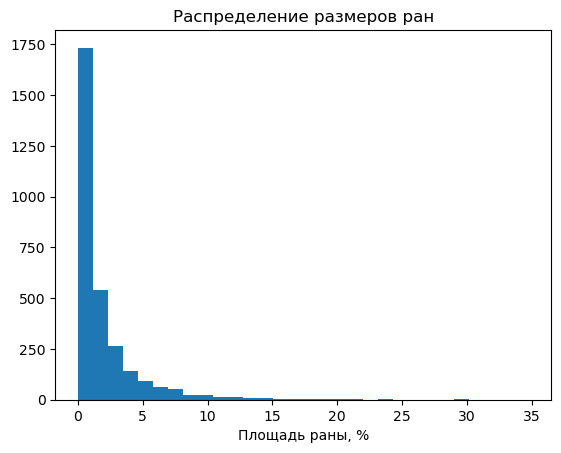

Медиана площади: 0.90%
Диапазон: 0.00% – 34.75%
Маленьких ран (<0.4 %): 803 из 3010
Больших ран(>2.2 %): 767 из 3010


In [96]:
# Гистограмма размера ран
plt.hist(df_meta["wound_ratio"] * 100, bins=30)
plt.xlabel("Площадь раны, %")
plt.title("Распределение размеров ран")
plt.show()

# Статистики
print(f"Медиана площади: {df_meta['wound_ratio'].median()*100:.2f}%")
print(f"Диапазон: {df_meta['wound_ratio'].min()*100:.2f}% – {df_meta['wound_ratio'].max()*100:.2f}%")

# Фильтрация: найти очень маленькие раны, очень большие раны
small_wounds = df_meta[df_meta["wound_ratio"] < 0.004]
print(f"Маленьких ран (<0.4 %): {len(small_wounds)} из {len(df_meta)}")
big_wounds = df_meta[df_meta["wound_ratio"] > 0.022]
print(f"Больших ран(>2.2 %): {len(big_wounds)} из {len(df_meta)}")

Теперь необходимо разбить полученные данные на трейн, валидацию и тест, используя стратифицированный сплит по источнику данных и размеру раны.

In [97]:
# Категоризация размера (по порогам из EDA)
bins = [-np.inf, 0.004, 0.022, np.inf]   # small <0.4%, medium 0.4-2.8%, large >2.8%
labels = ['small', 'medium', 'large']
df_meta['size_category'] = pd.cut(df_meta['wound_ratio'], bins=bins, labels=labels)

# Страта = источник + размер
df_meta['strata'] = df_meta['source'] + '_' + df_meta['size_category'].astype(str)
df_meta

,idx,source,wound_ratio,size_category,strata
0,0,FuSeg,0.035385,large,FuSeg_large
1,1,FuSeg,0.005238,medium,FuSeg_medium
2,2,FuSeg,0.016571,medium,FuSeg_medium
3,3,FuSeg,0.021812,medium,FuSeg_medium
4,4,FuSeg,0.001591,small,FuSeg_small
...,...,...,...,...,...
3005,1995,DFUC,0.010742,medium,DFUC_medium
3006,1996,DFUC,0.005605,medium,DFUC_medium
3007,1997,DFUC,0.004883,medium,DFUC_medium
3008,1998,DFUC,0.003545,small,DFUC_small


In [98]:
# 70% train, 15% val, 15% test
split1 = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=42)
train_idx, temp_idx = next(split1.split(df_meta, df_meta['strata']))

# Из временных 30% берём половину на val, половину на test
temp_df = df_meta.iloc[temp_idx]
split2 = StratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=42)
val_idx_local, test_idx_local = next(split2.split(temp_df, temp_df['strata']))

# Глобальные индексы
train_indices = df_meta.iloc[train_idx].index.tolist()
val_indices   = temp_df.iloc[val_idx_local].index.tolist()
test_indices  = temp_df.iloc[test_idx_local].index.tolist()

print(f"Train: {len(train_indices)}, Val: {len(val_indices)}, Test: {len(test_indices)}")

Train: 2107, Val: 451, Test: 452


In [99]:
def make_full_dataset(transform):
    return ConcatDataset([
        FUSegBaseline(str(FUSEG_ROOT), split='train', transform=transform),
        FUSegBaseline(str(FUSEG_ROOT), split='validation', transform=transform),
        DFUC(str(DFUC_ROOT), transform=transform)
    ])
# чтобы не смешивать разные аугментации, создаем три одинаковых датасета, и проводим соответствующие изменения над каждым из них
full_train_ds = make_full_dataset(train_tf)
full_val_ds   = make_full_dataset(val_tf)
full_test_ds  = make_full_dataset(test_tf)

train_ds = Subset(full_train_ds, train_indices)
val_ds   = Subset(full_val_ds, val_indices)
test_ds  = Subset(full_test_ds, test_indices)

Создаем даталоадеры для трейна, валидации и теста.

In [100]:
random.seed(42)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True, num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=8, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=8, shuffle=False, num_workers=0, pin_memory=True)

В соревновании по датасету `FuSeg` призеры использовали функцию потерь **Dice + Focal Loss**. Благодаря данной функции потерь можно использовать преимущества обеих функций.<br>
*Dice Loss* хорошо работает с несбалансированными данными (когда площадь объекта мала по сравнению с фоном).<br>
*Focal Loss* фокусируется на сложных примерах, снижая вклад легко классифицируемых пикселей.<br>

Итоговая функция потерь вычисляется как взвешенная сумма.

In [101]:
class DiceFocalLoss(nn.Module):
    """
    Комбинация Dice Loss + Focal Loss (как в FUSeg Rank 1).

    Args:
        dice_weight: вес Dice-компоненты 
        focal_weight: вес Focal-компоненты
        focal_gamma: параметр фокусировки
        focal_alpha: баланс классов для Focal
    """
    def __init__(self, dice_weight=1.0, focal_weight=0.5,
                 focal_gamma=2.0, focal_alpha=0.25):
        super().__init__()
        self.dice_weight = dice_weight
        self.focal_weight = focal_weight
        self.dice_loss = smp.losses.DiceLoss(mode='binary', smooth=1.0)
        self.focal_loss = smp.losses.FocalLoss(
            mode='binary',
            gamma=focal_gamma,
            alpha=focal_alpha
        )

    def forward(self, logits, targets):
        targets = targets.float()
        loss_dice = self.dice_loss(logits, targets)
        loss_focal = self.focal_loss(logits, targets)
        return self.dice_weight * loss_dice + self.focal_weight * loss_focal

Для эксперимента будем использовать модель `Unet + MIT`. Также, как и в прошлых экспериментах, используем `decoder_dropout = 0.2`.
Модель загружаем на GPU.
Далее выбираем кастомную функцию потерь `DiceFocal Loss` , оптимизатор `AdamW`, шедулер с контролем выхода на плато при нахождении оптимума.

In [102]:
WEIGHTS_DIR = Path("../../src/weights") # папка для сохранения весов модели
WEIGHTS_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = smp.Unet(encoder_name='mit_b1', encoder_weights='imagenet',
                      in_channels=3, classes=1, activation=None, decoder_dropout=0.2).to(device)
criterion = DiceFocalLoss(
    dice_weight=1.0,      # Dice — основная метрика
    focal_weight=0.5,     # Focal — вспомогательная стабилизация
    focal_gamma=2.0,      # Стандартное значение
    focal_alpha=0.25      # Усиливает штраф за пропуск раны (класс 1)
)
optimizer = AdamW(model.parameters(), lr=2e-4, weight_decay=5e-4)
scheduler = ReduceLROnPlateau(optimizer, mode='max', patience=3, factor=0.5)

In [ ]:
random.seed(42)


best_model_path = WEIGHTS_DIR / "update_model_dataset_mit.pth" # имя файла с весами модели

# создаем счетчики для лучшего Dice, лучшей функции потерь на валидационной выборке и счетчик для предотвращения переобучения модели.
best_dice = 0.0
best_val_loss = float('inf')
patience_counter = 0
max_epochs = 40 # обучаем модель на 40 эпохах

for epoch in range(1, max_epochs + 1):
    model.train()
    train_loss = 0
    with tqdm(train_loader, desc=f"Epoch {epoch:02d}/{max_epochs} [Train]", leave=False) as pbar:
        for batch in pbar:
            x, y = batch['image'].to(device), batch['mask'].float().unsqueeze(1).to(device)
            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item()
            pbar.set_postfix(loss=f"{loss.item():.4f}")
    train_loss /= len(train_loader)

    model.eval()
    val_loss = 0.0
    tp, fp, fn, tn = 0, 0, 0, 0
    with torch.no_grad():
        with tqdm(val_loader, desc=f"Epoch {epoch:02d}/{max_epochs} [Val]  ", leave=False) as pbar:
            for batch in pbar:
                x, y = batch['image'].to(device), batch['mask'].float().unsqueeze(1).to(device)
                logits = model(x)
                val_loss += criterion(logits, y).item()

                pred = torch.sigmoid(logits) > 0.5
                pred = pred.to(device).float()
                tp += (pred * y).sum().item()
                fp += (pred * (1 - y)).sum().item()
                fn += ((1 - pred) * y).sum().item()
                tn += ((1 - pred) * (1 - y)).sum().item()


    val_loss /= len(val_loader)
    dice = 2 * tp / (2 * tp + fp + fn + 1e-6) # расчет метрик
    iou  = tp / (tp + fp + fn + 1e-6)
    precision = tp / (tp + fp + 1e-6)
    recall = tp / (tp + fn + 1e-6)
    scheduler.step(dice)

    print(f"Epoch {epoch:02d} | "
          f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
          f"Dice: {dice:.4f} | IoU: {iou:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f} | LR: {optimizer.param_groups[0]['lr']:.1e}")

    if dice > best_dice:
        best_dice = dice
        best_val_loss = val_loss
        torch.save({                  # сохранение лучших параметров модели, полученных при обучении
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_dice': dice,
            'val_loss': val_loss,
            'IoU': iou,
            'precision': precision,
            'recall': recall,
        }, best_model_path)
        print(f"Сохранена лучшая модель | Dice: {dice:.4f} | Path: {best_model_path}")
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= 4:                 # для предотвращения переобучения введен порог. Если модель в течение 4 эпох
            print("Early stopping triggered")     # не улучшает значение Dice на валидационной выборке, то обучение прерывается
            break

In [ ]:
model_update = torch.load("../../src/weights/update_model_dataset_mit.pth", map_location=device)

In [104]:
print(f"Эпоха с лучшими значениями: {model_update['epoch']},"
f" Функция потерь: {model_update['val_loss']:.4f},"
f" Dice: {model_update['val_dice']:.4f},"
f" IoU: {model_update['IoU']:.4f},"
f" Precision: {model_update['precision']:.4f},"
f" Recall: {model_update['recall']:.4f}")

Эпоха с лучшими значениями: 7, Функция потерь: 0.1926, Dice: 0.8289, IoU: 0.7078, Precision: 0.8001, Recall: 0.8599


Теперь проверим полученную модель на отложенной тестовой выборке, не участвующей в обучении.

In [105]:
random.seed(42)

model = smp.Unet(encoder_name='mit_b1', encoder_weights=None,
                      in_channels=3, classes=1, activation=None, decoder_dropout=0.2).to(device)
checkpoint = torch.load("../../src/weights/update_model_dataset_mit.pth")
model.load_state_dict(checkpoint['model_state_dict'])

tp, fp, fn, tn = 0, 0, 0, 0

model.eval()
with torch.no_grad():
    for batch in tqdm(test_loader, desc="Оценка"):
        x, y = batch['image'].to(device), batch['mask'].float().unsqueeze(1).to(device)
        logits = model(x)

        pred = torch.sigmoid(logits) > 0.5
        pred = pred.to(device).float()
        tp += (pred * y).sum().item()
        fp += (pred * (1 - y)).sum().item()
        fn += ((1 - pred) * y).sum().item()
        tn += ((1 - pred) * (1 - y)).sum().item()

dice = 2 * tp / (2 * tp + fp + fn + 1e-6)
iou  = tp / (tp + fp + fn + 1e-6)
precision = tp / (tp + fp + 1e-6)
recall = tp / (tp + fn + 1e-6)

Оценка: 100%|██████████| 57/57 [00:11<00:00,  4.97it/s]


In [106]:
print(f" Dice: {dice:.4f},"
f" IoU: {iou:.4f},"
f" Precision: {precision:.4f},"
f" Recall: {recall:.4f}")

 Dice: 0.8175, IoU: 0.6913, Precision: 0.7899, Recall: 0.8470


Для сравнения на тесте испытаем также модель `Unet + MIT`из прошлого урока, не предобученную на новых данных.

In [107]:
random.seed(42)

model = smp.Unet(encoder_name='mit_b1', encoder_weights=None,
                      in_channels=3, classes=1, activation=None, decoder_dropout=0.2).to(device)
checkpoint = torch.load("../../src/weights/baseline_mit_best.pth")
model.load_state_dict(checkpoint['model_state_dict'])

tp, fp, fn, tn = 0, 0, 0, 0

model.eval()
with torch.no_grad():
    for batch in tqdm(test_loader, desc="Оценка"):
        x, y = batch['image'].to(device), batch['mask'].float().unsqueeze(1).to(device)
        logits = model(x)

        pred = torch.sigmoid(logits) > 0.5
        pred = pred.to(device).float()
        tp += (pred * y).sum().item()
        fp += (pred * (1 - y)).sum().item()
        fn += ((1 - pred) * y).sum().item()
        tn += ((1 - pred) * (1 - y)).sum().item()

dice = 2 * tp / (2 * tp + fp + fn + 1e-6)
iou  = tp / (tp + fp + fn + 1e-6)
precision = tp / (tp + fp + 1e-6)
recall = tp / (tp + fn + 1e-6)

Оценка: 100%|██████████| 57/57 [00:11<00:00,  4.91it/s]


In [108]:
print(f" Dice: {dice:.4f},"
f" IoU: {iou:.4f},"
f" Precision: {precision:.4f},"
f" Recall: {recall:.4f}")

 Dice: 0.7329, IoU: 0.5785, Precision: 0.7704, Recall: 0.6990


**Для наглядности сведем результаты в таблицу (оценка моделей на тесте)**

| Параметр | Unet + MIT(1 датасет)| Unet + MIT (2 датасета)|
|----------|----------|----------|
| **Dice** | 0.7329| 0.8175|
| **IoU** | 0.5785| 0.6913|
| **Precision** | 0.7704 | 0.7899|
| **Recall** | 0.6990 | 0.8470|

Как видно из результатов, значения метрик второй модели сильно превосходят первую. Высокий уровень `Dice` достигается за счет увеличения `Recall` у второй модели. То есть, можно было бы сделать вывод, что вторая модель имеет лучшую обобщающую способность.<br>
Однако, несмотря на то, что изначально данная тестовая выборка была отделена от остальной части датасета, фотосъемка и разметка все равно выполнена в похожих условиях, что и оставшаяся часть, которая ушла в трейн. Другого датасета для проверки найти не удалось.<br>
Таким образом, данный эксперимент показывает, что увеличение объема данных, использование данных, которые есть в клинике, предобучение на них модели должны улучшить обобщающую способность и значительно повысить качество продукта. Также  применённые аугментации (повороты, масштабирование, CLAHE, цветовые искажения, шумы) компенсируют различия в условиях съёмки (освещение, камера, фон) и повышают устойчивость модели к вариативности реальных данных.

#### 2. Улучшенная архитектура модели

В качестве улучшенной архитектуры можно рассмотреть ансамблирование моделей. Часто при ансамблировании моделей с разными архитектурами можно получить лучшие результаты.
Для этого загрузим `Unet + MIT` и `Unet+ efficientnet-b0`и протестриуем на отложенных данных.

In [110]:
random.seed(42)

model_1 = smp.Unet(encoder_name='timm-efficientnet-b0', encoder_weights=None,
                      in_channels=3, classes=1, activation=None, decoder_dropout=0.2).to(device)
checkpoint = torch.load("../../src/weights/baseline_best.pth")
model_1.load_state_dict(checkpoint['model_state_dict'])
model_1.eval()
model_2 = smp.Unet(encoder_name='mit_b1', encoder_weights=None,
                   in_channels=3, classes=1, activation=None, decoder_dropout=0.2).to(device)
checkpoint = torch.load("../../src/weights/baseline_mit_best.pth")
model_2.load_state_dict(checkpoint['model_state_dict'])
model_2.eval()

models = [model_1, model_2]


tp, fp, fn, tn = 0, 0, 0, 0
with torch.no_grad():
    for batch in tqdm(test_loader, desc="Оценка"):
        x, y = batch['image'].to(device), batch['mask'].float().unsqueeze(1).to(device)
        logits_ensemble = torch.zeros_like(model_1(x))  # инициализация нулями
        for model in models:
            logits_ensemble += model(x)
        logits_ensemble /= len(models)   
        pred = torch.sigmoid(logits_ensemble) > 0.5
        pred = pred.to(device).float()
        tp += (pred * y).sum().item()
        fp += (pred * (1 - y)).sum().item()
        fn += ((1 - pred) * y).sum().item()
        tn += ((1 - pred) * (1 - y)).sum().item()

dice = 2 * tp / (2 * tp + fp + fn + 1e-6)
iou  = tp / (tp + fp + fn + 1e-6)
precision = tp / (tp + fp + 1e-6)
recall = tp / (tp + fn + 1e-6)

Оценка: 100%|██████████| 57/57 [00:20<00:00,  2.83it/s]


In [111]:
print(f" Dice: {dice:.4f},"
f" IoU: {iou:.4f},"
f" Precision: {precision:.4f},"
f" Recall: {recall:.4f}")

 Dice: 0.7506, IoU: 0.6008, Precision: 0.8925, Recall: 0.6477


Ниже представлена сводная таблица со значениями на тестовой выборке моделей `Unet + MIT`, `DeepLabV3 + efficientnet-b0` и их ансамбля.

| Параметр | Unet + efficientnet-b0| Unet + mit_b1| Ансамбль моделей|
|----------|----------|----------|----------|
| **Dice** | 0.7463| 0.7329| 0.7506|
| **IoU** | 0.5953| 0.5785| 0.6008|
| **Precision** | 0.9092 | 0.7704| 0.8925|
| **Recall** | 0.6329 | 0.6990| 0.6477|

Как видно, за счет синергии моделей ансамбль достигает лучших значений метрик `Dice` и `IoU`. При этом в ансамбле точность немного ниже по сравнению с чистой `Unet + efficientnet-b0`, а полнота немного ниже по сравнению с `Unet + MIT`.

#### 3. Постобработка предсказаний

В качестве постобработки предсказаний реализована функция, удаляющая мелкие по площади объекты и выполняющая морфологическое закрытие (заполнение небольших промежутков в области). 
Часто модель может давать ложные маленькие срабатывания на шуме или границах стопы. Удаление таких объектов повышает точность (`Precision`).
А морфологическое сглаживание повышает `Dice`.

In [79]:
# функция постобработки предсказаний
def postprocess_mask(mask, min_area=100, kernel_size=5):
    """
    mask: numpy-массив размером (H, W) с значениями 0 или 1 (uint8)
    возвращает обработанную маску (numpy, uint8)
    """
    # Удаление мелких объектов
    contours, _ = cv2.findContours(mask * 255, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    for cnt in contours:
        if cv2.contourArea(cnt) < min_area:
            cv2.drawContours(mask, [cnt], -1, 0, -1)

    # Заполнение дырок (морфологическое закрытие)
    kernel = np.ones((kernel_size, kernel_size), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    return mask

Применим постобработку на тестовой выборке на модели `Unet + mit`.

In [80]:
random.seed(42)

model = smp.Unet(encoder_name='mit_b1', encoder_weights=None,
                      in_channels=3, classes=1, activation=None, decoder_dropout=0.2).to(device)
checkpoint = torch.load("../../src/weights/baseline_mit_best.pth")
model.load_state_dict(checkpoint['model_state_dict'])

tp, fp, fn, tn = 0, 0, 0, 0

model.eval()
with torch.no_grad():
    for batch in tqdm(test_loader, desc="Оценка"):
        x, y = batch['image'].to(device), batch['mask'].float().unsqueeze(1).to(device)
        logits = model(x)

        pred = torch.sigmoid(logits) > 0.5
        pred = pred.to(device).float()
        for i in range(pred.size(0)):
            mask_np = pred[i, 0].cpu().numpy().astype(np.uint8)
            mask_np = postprocess_mask(mask_np, min_area=100, kernel_size=5)
            pred[i, 0] = torch.from_numpy(mask_np.astype(np.float32))

        tp += (pred * y).sum().item()
        fp += (pred * (1 - y)).sum().item()
        fn += ((1 - pred) * y).sum().item()
        tn += ((1 - pred) * (1 - y)).sum().item()

dice = 2 * tp / (2 * tp + fp + fn + 1e-6)
iou  = tp / (tp + fp + fn + 1e-6)
precision = tp / (tp + fp + 1e-6)
recall = tp / (tp + fn + 1e-6)

Оценка: 100%|██████████| 57/57 [00:12<00:00,  4.64it/s]


In [81]:
print(f" Dice: {dice:.4f},"
f" IoU: {iou:.4f},"
f" Precision: {precision:.4f},"
f" Recall: {recall:.4f}")

 Dice: 0.7343, IoU: 0.5801, Precision: 0.7725, Recall: 0.6997


**Для наглядности сведем результаты в таблицу (оценка моделей на тесте)**

| Параметр | Unet + mit (без постобработки)| Unet + mit (с постобработкой)|
|----------|----------|----------|
| **Dice** | 0.7329| 0.7343|
| **IoU** | 0.5785| 0.5801|
| **Precision** | 0.7704 | 0.7725|
| **Recall** | 0.6990 | 0.6997|

Добавление постобработки незначительно сказалось на изменениях метрик. Однако при обработке новых данных этот инструмент может быть полезен.

Также хотел в этой части упомянуть про `TTA (Test-Time Augmentation)`, как про дополнительный эксперимент, который может быть использован в инференсе для итоговых предсказаний. С помощью данного метода также можно повысить качество. Функция TTA представлена ниже.

In [82]:
def tta_predict(model, img_tensor, device, threshold=0.5):
    # TTA с 5 аугментациями + усреднение вероятностей
    # Здесь использовались оригинальный снимок, повороты стопы на 90, 180, 270 градусов, а также flip.
    preds = []
    transforms = [
        lambda x: x,
        lambda x: torch.flip(x, [-1]),
        lambda x: torch.rot90(x, k=1, dims=[-2,-1]),
        lambda x: torch.rot90(x, k=2, dims=[-2,-1]),
        lambda x: torch.rot90(x, k=3, dims=[-2,-1])
    ]
    inverses = [
        lambda x: x,
        lambda x: torch.flip(x, [-1]),
        lambda x: torch.rot90(x, k=-1, dims=[-2,-1]),
        lambda x: torch.rot90(x, k=-2, dims=[-2,-1]),
        lambda x: torch.rot90(x, k=-3, dims=[-2,-1])
    ]
    with torch.no_grad():
        for t, inv in zip(transforms, inverses):
            aug = t(img_tensor.to(device))
            prob = torch.sigmoid(model(aug)).cpu()
            preds.append(inv(prob))
    prob_map = torch.stack(preds).mean(dim=0)
    mask = (prob_map > threshold).float()
    return prob_map, mask

In [83]:
random.seed(42)

model = smp.Unet(encoder_name='mit_b1', encoder_weights=None,
                   in_channels=3, classes=1, activation=None, decoder_dropout=0.2).to(device)
checkpoint = torch.load("../../src/weights/baseline_mit_best.pth")
model.load_state_dict(checkpoint['model_state_dict'])

tp, fp, fn, tn = 0, 0, 0, 0

model.eval()
with torch.no_grad():
    for batch in tqdm(test_loader, desc="Оценка"):
        x, y = batch['image'].to(device), batch['mask'].float().unsqueeze(1).to(device)
        logits = model(x)
        _, pred = tta_predict(model, x, device, threshold=0.5)
        pred = pred.to(device).float()

        tp += (pred * y).sum().item()
        fp += (pred * (1 - y)).sum().item()
        fn += ((1 - pred) * y).sum().item()
        tn += ((1 - pred) * (1 - y)).sum().item()

dice = 2 * tp / (2 * tp + fp + fn + 1e-6)
iou  = tp / (tp + fp + fn + 1e-6)
precision = tp / (tp + fp + 1e-6)
recall = tp / (tp + fn + 1e-6)

Оценка: 100%|██████████| 57/57 [00:38<00:00,  1.49it/s]


In [84]:
print(f" Dice: {dice:.4f},"
f" IoU: {iou:.4f},"
f" Precision: {precision:.4f},"
f" Recall: {recall:.4f}")

 Dice: 0.7493, IoU: 0.5991, Precision: 0.8007, Recall: 0.7041


| Параметр | Unet + MIT| Unet + MIT (TTA)|
|----------|----------|----------|
| **Dice** | 0.7329| 0.7493|
| **IoU** | 0.5785| 0.5991|
| **Precision** | 0.7704 | 0.8007|
| **Recall** | 0.6990 | 0.7041|

При усреднении предсказаний TTA на модели `Unet + MIT` метрики существенно вырастают. Однако следует учесть, что внедрение данного метода серьезно замедляет ответ модели. Также следует отметить, что данный метод ухудшает значение метрик у модели `DeepLabV3 + efficientnet-b0` из-за наличия у нее модуля ASPP (Atrous Spatial Pyramid Pooling), благодаря которому модель и так по разному "смотрит" на изображение. Дополнительные повороты не дают ей новой информации, а только вносят шум от интерполяции.

#### 4. Подробный анализ качества модели в разрезе метрик

1. Наиболее критичной для продукта является метрика `Dice` – она отражает баланс между полнотой и точностью, что критично для врачебной оценки динамики заживления.

2. `Recall` важен для выявления всех патологических участков, но избыточные ложные срабатывания (низкая `Precision`) могут дезориентировать врача.

3. Объединение датасетов – самый эффективный способ улучшить все метрики, особенно `Recall`. Основной упор в дальнейшем следует делать на сбор и разметку клинических данных, поскольку увеличение объёма выборки даёт наибольший эффект.

4. Постобработка и TTA – вспомогательные инструменты, которые дают небольшой, но стабильный прирост, и их стоит применять в финальной версии системы для работы с новыми данными.

5. Влияние TTA на разные архитектуры:

 `Unet + MIT` – TTA улучшает `Dice` за счёт роста `IoU`, при этом `Precision` и `Recall` остаются сбалансированными.
 `DeepLabV3 + efficientnet` – TTA ухудшает `Dice` из-за падения Recall. ASPP-модуль уже обеспечивает мультимасштабность, и лишние повороты вносят шум.

6. Сравнение моделей:

 `Unet + efficientnet` даёт высокую `Precision` (0.9092) – редко ошибается, но пропускает часть язвы (низкий `Recall`).
 `Unet + MIT` с TTA имеет более высокий `Recall` (0.7041) и сбалансированный `Dice` – лучше находит язвы, но даёт больше ложных срабатываний (`Precision` 0.8007).
Ансамбль этих двух моделей без TTA  улучшает Precision за счёт `Unet + efficientnet`.

**Выводы: для клинического применения наиболее важен `Dice`, так как он отражает баланс между полнотой и точностью. Модель `Unet + MIT`с TTA, предобученная на двух датасетах обеспечивает наилучший Dice (0.8283) и IoU (0.7069) среди всех протестированных конфигураций. Это делает её предпочтительным выбором для продукта.**

In [85]:
random.seed(42)

model = smp.Unet(encoder_name='mit_b1', encoder_weights=None,
                   in_channels=3, classes=1, activation=None, decoder_dropout=0.2).to(device)
checkpoint = torch.load("../../src/weights/update_model_dataset_mit.pth")
model.load_state_dict(checkpoint['model_state_dict'])

tp, fp, fn, tn = 0, 0, 0, 0

model.eval()
with torch.no_grad():
    for batch in tqdm(test_loader, desc="Оценка"):
        x, y = batch['image'].to(device), batch['mask'].float().unsqueeze(1).to(device)
        logits = model(x)
        _, pred = tta_predict(model, x, device, threshold=0.5)
        pred = pred.to(device).float()

        tp += (pred * y).sum().item()
        fp += (pred * (1 - y)).sum().item()
        fn += ((1 - pred) * y).sum().item()
        tn += ((1 - pred) * (1 - y)).sum().item()

dice = 2 * tp / (2 * tp + fp + fn + 1e-6)
iou  = tp / (tp + fp + fn + 1e-6)
precision = tp / (tp + fp + 1e-6)
recall = tp / (tp + fn + 1e-6)

Оценка: 100%|██████████| 57/57 [00:38<00:00,  1.48it/s]


In [86]:
print(f" Dice: {dice:.4f},"
f" IoU: {iou:.4f},"
f" Precision: {precision:.4f},"
f" Recall: {recall:.4f}")

 Dice: 0.8283, IoU: 0.7069, Precision: 0.8127, Recall: 0.8445
